In [33]:
# Import Libraries

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.tree import export_text
from sklearn.preprocessing import MinMaxScaler

In [44]:
# Read in Data from CSV
raw_data = np.genfromtxt("C:/Users/temps/Documents/GitHub/Bionic-Hand-Scripts/data/Spring 2026/lk_pressed_highpos.csv", delimiter=',')
# Convert Integer Time to Float ime
# Since we will have several readings with the same time in the csv, 
# we have to split these up by millisecond intervals
# If we have five readings at 67 seconds, we will split them up into 5 time slots
# 67.0, 67.2, 67.4, 67.6, 67.8


running_list_x = []
running_list_y = []
# Final values to be stored in the DataFrame
final_x = []
final_y = []

# Create a MinMaxScaler instance
scaler = MinMaxScaler()

print(raw_data)

prev = 0
total = 0
for x,y in raw_data:
    
    final_x.append(x)
    final_y.append(y)
    


# Normalize the final_y values
final_x = np.array(final_x).reshape(-1, 1)  # Reshape to 2D
final_x = scaler.fit_transform(final_x).flatten()  # Flatten back to 1D
final_y = np.array(final_y)*1e-6

[[3.10000000e+01 1.26593800e+07]
 [3.00000000e+01 1.26700080e+07]
 [3.10000000e+01 1.26806360e+07]
 ...
 [5.70000000e+01 1.36050108e+08]
 [5.10000000e+01 1.36060772e+08]
 [4.70000000e+01 1.36071444e+08]]


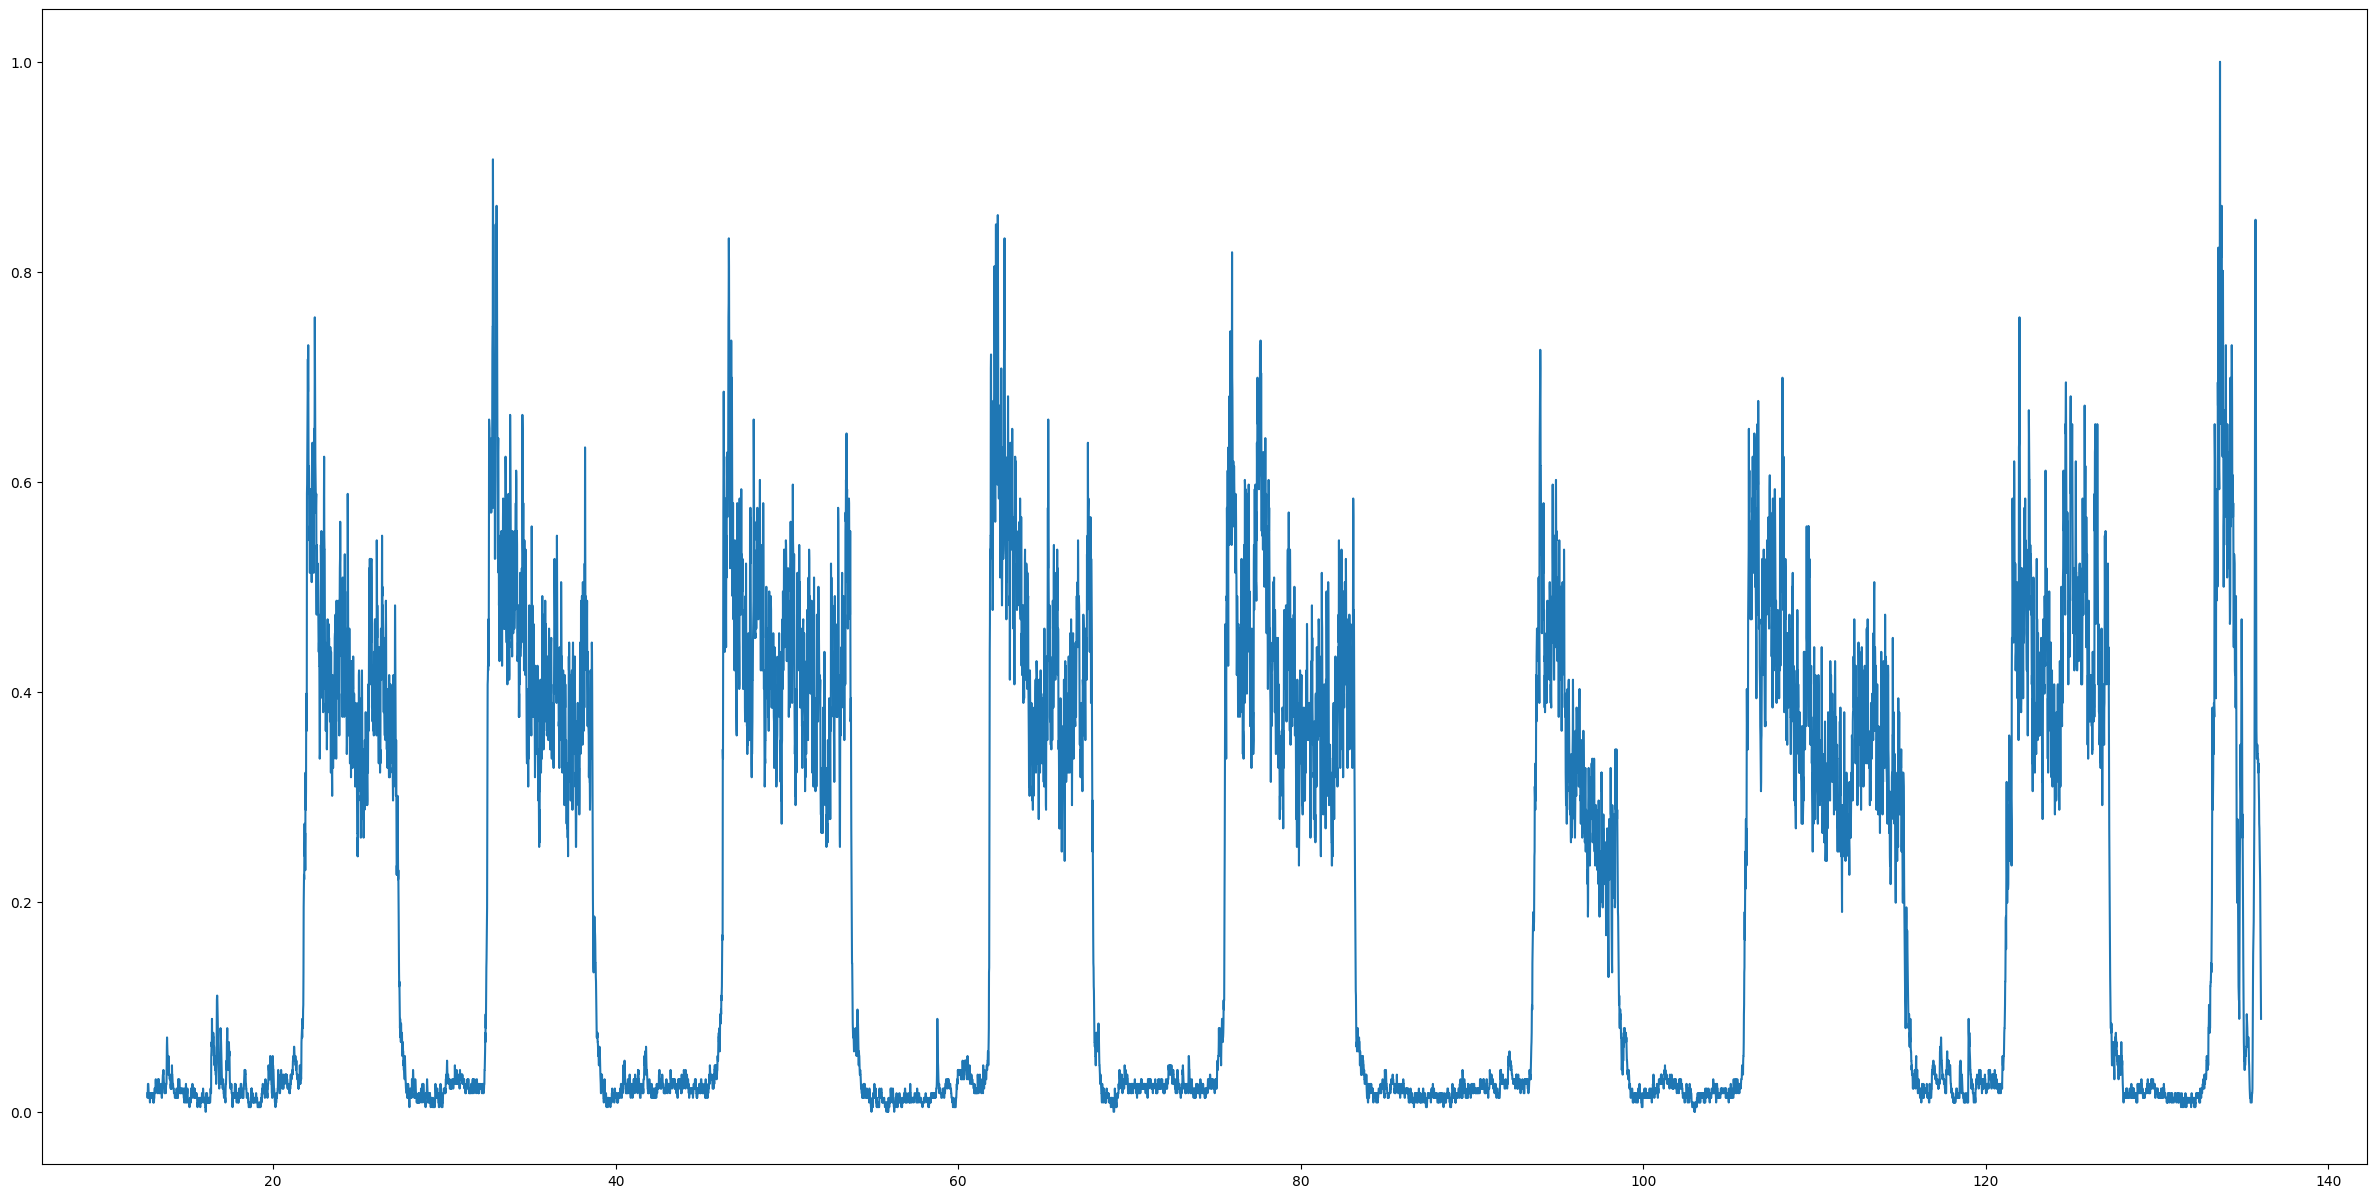

,Time,Signal
0,0.000000,0.013274
1,0.010628,0.017699
2,0.021244,0.026549
3,0.031876,0.026549
4,0.042492,0.026549


11582


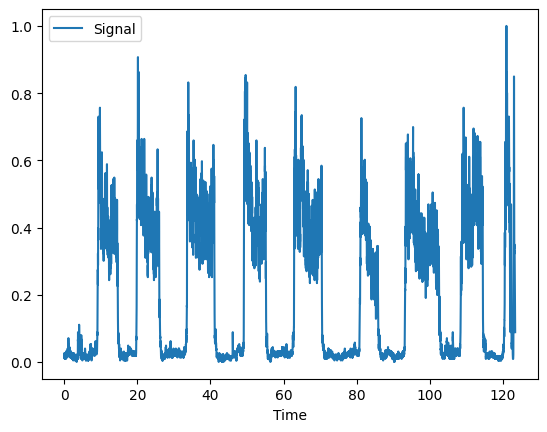

In [45]:
# Initial Plot
plt.figure(figsize=(30, 15))
plt.plot(final_y, final_x)
plt.show()

# Create a Pandas DataFrame
orignal = pd.DataFrame({"Time": final_y[1:], "Signal": final_x[1:]})

# Filter out data before the start time
#df = orignal[orignal["Time"] > ].copy()
df = orignal.copy()

#Standardize time so the first point is at 0 seconds
df["Time"] = df["Time"] - min(df["Time"])


# Print
display(df.head())
print(len(df))

#df = df[df["Time"] < 80000000].copy()

# Final Plot
plot = df.plot(x="Time",y='Signal')

plt.show()

In [46]:
#Known open and closed intervals
interval_times_1 = [5.15, 4.53, 5.35, 5.25, 4.73, 5.03, 5.31, 4.38, 5.15, 5.31, 4.70, 4.75]

interval_times_2 = [10.08, 5.33, 5.20, 6.76, 6.91, 7.86, 7.63, 6.43, 7.26, 8.45, 10.00, 5.10, 7.33, 9.26, 5.73, 6.05, 5.46]

interval_times_3 = [7.03, 10.06, 8.03, 10.33, 4.86, 6.01, 7.93, 10.08, 9.58, 5,11, 6.35, 9.56, 5.43, 6.73, 5.30, 7.88, 1.08]

-0.8 - 9.28
9.28 - 14.61
14.61 - 19.81
19.81 - 26.57
26.57 - 33.480000000000004
33.480000000000004 - 41.34
41.34 - 48.970000000000006
48.970000000000006 - 55.400000000000006
55.400000000000006 - 62.660000000000004
62.660000000000004 - 71.11
71.11 - 81.11
81.11 - 86.21
86.21 - 93.53999999999999
93.53999999999999 - 102.8
102.8 - 108.53
108.53 - 114.58
114.58 - 120.03999999999999


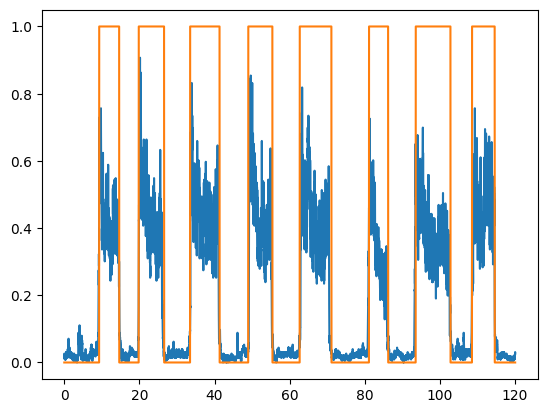

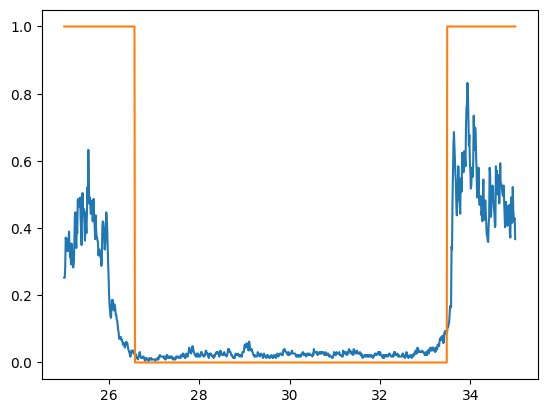

           Time    Signal  State
2350  25.009996  0.252212    1.0
2351  25.020620  0.252212    1.0
2352  25.031236  0.283186    1.0
2353  25.041916  0.371681    1.0
2354  25.052592  0.362832    1.0
...         ...       ...    ...
3285  34.952784  0.455752    1.0
3286  34.963468  0.433628    1.0
3287  34.974144  0.424779    1.0
3288  34.984816  0.429204    1.0
3289  34.995496  0.367257    1.0

[940 rows x 3 columns]


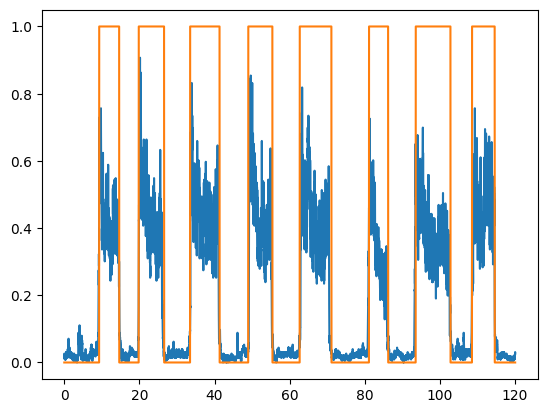

In [51]:
# Throw out data before here
interval_times = interval_times_2

start_time = -0.8

# Label each point with a State based on the interval
for i in range(len(interval_times)):
    end_time = start_time + interval_times[i]
    print(f"{start_time} - {end_time}")
    df.loc[df["Time"].between(start_time, end_time), "State"] = i%2
            
    start_time = end_time
    
# Plot Data
plt.plot(df["Time"], df["Signal"])
plt.plot(df["Time"], df["State"])

# Removes any numbers which are infinity or NaN
df = df[df["State"].apply(lambda x: not (pd.isna(x) or x in [float('inf'), float('-inf')]))]

plt.show()

df_section = df[df['Time'].between(25, 35)].copy()
plt.plot(df_section["Time"], df_section["Signal"])
plt.plot(df_section["Time"], df_section["State"])
plt.show()

print(df[df['Time'].between(25, 35)])


plt.plot(df["Time"], df["Signal"])
plt.plot(df["Time"], df["State"])


In [52]:
def percentile20(data):
    return np.percentile(data,20)


def skew(data):
    mean = np.mean(data)
    std = np.std(data)
    N = np.size(data)
    top = np.sum((data - mean)**3)
    bottom = (N-1)*(std**3)
    total = top/(bottom + 0.0000001)
    return total

def kurtosis(data):
    mean = np.mean(data)
    top = np.sum((data - mean)**4)
    bottom = np.sum((data - (mean)**2)**2)
    total = top/(bottom + 0.00000001)
    return total

def stdfd(data):
    difference = np.diff(data)
    std = np.std(difference)
    return std

In [53]:
slice_length = 50

mean_list = []
max_list = []
min_list = []
range_list = []
last_list = []
second_list = []
perc_list = []
skew_list = []
kurt_list = []
stdiff_list = []
state_list = []

# Take slice_length number of signal points
for i in range(0, len(df) - slice_length + 1):
    current_frame = df.iloc[i: i + slice_length - 1]
    
    #plt.figure(figsize = (6,4))
    
    # Standard features
    mean_list.append(current_frame[ "Signal" ].mean())
    max_list.append(current_frame[ "Signal" ].max())
    min_list.append(current_frame[ "Signal" ].min())
    range_list.append(current_frame[ "Signal" ].max() - current_frame[ "Signal" ].min())
    
    perc_list.append(percentile20(current_frame[ "Signal" ]))
    skew_list.append(skew(current_frame[ "Signal" ]))
    kurt_list.append(kurtosis(current_frame[ "Signal" ]))
    stdiff_list.append(stdfd(current_frame["Signal"]))
    

    # Other features of interest
    last_list.append(current_frame.iloc[-1]["Signal"])
    second_list.append(current_frame.iloc[-2]["Signal"])
    
    # State, Y
    state_list.append(current_frame.iloc[-1]["State"])
    
# Make feature df for random forest
feature_df = pd.DataFrame({"Mean": mean_list, 
                           "Max": max_list, 
                           "Min": min_list, 
                           "Range": range_list,
                           "Last Val": last_list, 
                           "2nd Last Val": second_list, 
                           "Percentile": perc_list,
                           "Skew": skew_list,
                           "Kurtosis": kurt_list,
                           "Stdiff": stdiff_list,
                           "State": state_list
                          })


print (feature_df.tail(200))

           Mean       Max       Min     Range  Last Val  2nd Last Val  \
11018  0.016435  0.026549  0.008850  0.017699  0.008850      0.013274   
11019  0.016345  0.026549  0.008850  0.017699  0.013274      0.008850   
11020  0.016254  0.026549  0.008850  0.017699  0.008850      0.013274   
11021  0.016254  0.026549  0.008850  0.017699  0.013274      0.008850   
11022  0.016164  0.026549  0.008850  0.017699  0.008850      0.013274   
...         ...       ...       ...       ...       ...           ...   
11213  0.013997  0.022124  0.004425  0.017699  0.022124      0.022124   
11214  0.014268  0.022124  0.004425  0.017699  0.022124      0.022124   
11215  0.014539  0.026549  0.004425  0.022124  0.026549      0.022124   
11216  0.014809  0.026549  0.004425  0.022124  0.022124      0.026549   
11217  0.015351  0.030973  0.004425  0.026549  0.030973      0.022124   

       Percentile      Skew  Kurtosis    Stdiff  State  
11018    0.013274  0.550146  0.000002  0.003608    0.0  
11019    

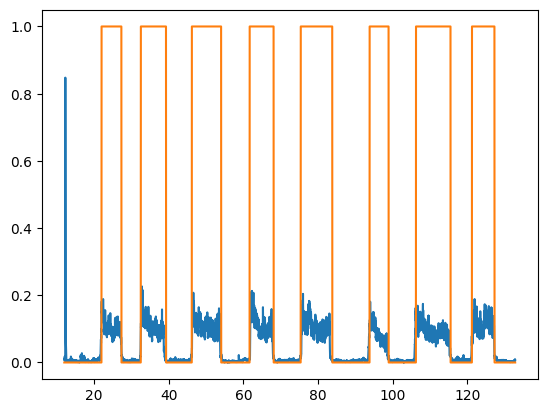

In [20]:
plt.plot(df["Time"], df["Signal"])
plt.plot(df["Time"], df["State"])
plt.show()

In [40]:
# Features and target
X = feature_df[["Mean", "Max", "Min", "Range", "Last Val", "2nd Last Val", "Percentile", "Skew", "Kurtosis", "Stdiff"]]  # Features
y = feature_df["State"]  # Target
y = y.astype(int)


# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


# Make random forest
model = RandomForestClassifier(random_state=42, max_features = "sqrt", max_depth = 6)
model.fit(X_train, y_train)


# Use test test for prediction
y_pred = model.predict(X_test)

# Evaluate the model
print("Classification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# Feature importance
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
}).sort_values(by="Importance", ascending=False)

print("\nFeature Importance:")
print(importance)

Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1837
           1       0.99      0.99      0.99      1529

    accuracy                           0.99      3366
   macro avg       0.99      0.99      0.99      3366
weighted avg       0.99      0.99      0.99      3366

Confusion Matrix:
[[1828    9]
 [  22 1507]]

Feature Importance:
        Feature  Importance
9        Stdiff    0.290280
0          Mean    0.257590
1           Max    0.157270
5  2nd Last Val    0.102717
4      Last Val    0.091989
6    Percentile    0.051992
2           Min    0.022640
3         Range    0.015995
8      Kurtosis    0.005745
7          Skew    0.003781


Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      0.99       788
           1       0.99      1.00      0.99       798

    accuracy                           0.99      1586
   macro avg       0.99      0.99      0.99      1586
weighted avg       0.99      0.99      0.99      1586

Confusion Matrix:
[[779   9]
 [  2 796]]
Coefficients: [[ 6.93964054  5.01518214  7.84359067 -2.82840853  9.54826952  9.52711255
   8.03829053  0.24439019 -0.1760783   0.23222432]]
Intercept: [-4.88151014]
log(p/(1-p)) = -4.88 + 6.94 * x1 + 5.02 * x2 + 7.84 * x3


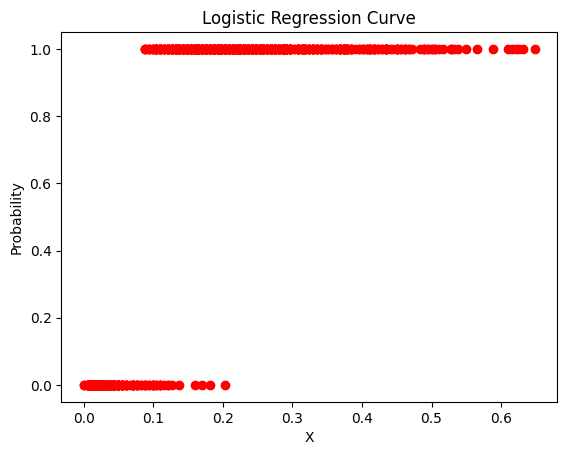

In [113]:
from sklearn.linear_model import LogisticRegression


# Features and target
logistic_X = feature_df[["Mean", "Max", "Min", "Range", "Last Val", "2nd Last Val", "Percentile", "Skew", "Kurtosis", "Stdiff"]]  # Features
logistic_y = feature_df["State"]  # Target
logistic_y = logistic_y.astype(int)


# Split data
logistic_X_train, logistic_X_test, logistic_y_train, logistic_y_test = train_test_split(logistic_X, logistic_y, test_size=0.2, random_state=42)

# Make logistic
logistic_model = LogisticRegression()
logistic_model.fit(logistic_X_train, logistic_y_train)


# Use test test for prediction
logistic_y_pred = model.predict(logistic_X_test)

# Evaluate the model
print("Classification Report:")
print(classification_report(logistic_y_test, logistic_y_pred))

# Confusion Matrix
print("Confusion Matrix:")
print(confusion_matrix(logistic_y_test, logistic_y_pred))

print("Coefficients:", logistic_model.coef_)
print("Intercept:", logistic_model.intercept_)

#Extract coefficients and intercept
coefficients = logistic_model.coef_[0]
intercept = logistic_model.intercept_[0]

# Construct the equation
equation = f"log(p/(1-p)) = {intercept:.2f} + {coefficients[0]:.2f} * x1 + {coefficients[1]:.2f} * x2 + {coefficients[2]:.2f} * x3"
print(equation)

# Plot the logistic regression curve
plt.scatter(logistic_X_test["Last Val"], logistic_y_pred, color='red')
plt.xlabel('X')
plt.ylabel('Probability')
plt.title('Logistic Regression Curve')
plt.show()


In [114]:
# Assuming your RandomForest model is already trained
# Extract the first decision tree from the Random Forest
tree = model.estimators_[0]

# Get the decision rules for the tree
tree_rules = export_text(tree, feature_names=X.columns.tolist())

# Print the decision rules (splits and thresholds used in the first tree)
print(tree_rules)

|--- Last Val <= 0.09
|   |--- Percentile <= 0.09
|   |   |--- Skew <= 2.77
|   |   |   |--- class: 0.0
|   |   |--- Skew >  2.77
|   |   |   |--- Skew <= 2.86
|   |   |   |   |--- class: 1.0
|   |   |   |--- Skew >  2.86
|   |   |   |   |--- class: 0.0
|   |--- Percentile >  0.09
|   |   |--- Stdiff <= 0.02
|   |   |   |--- class: 1.0
|   |   |--- Stdiff >  0.02
|   |   |   |--- class: 0.0
|--- Last Val >  0.09
|   |--- Last Val <= 0.11
|   |   |--- Max <= 0.21
|   |   |   |--- Kurtosis <= 0.00
|   |   |   |   |--- class: 1.0
|   |   |   |--- Kurtosis >  0.00
|   |   |   |   |--- Max <= 0.14
|   |   |   |   |   |--- Range <= 0.09
|   |   |   |   |   |   |--- class: 1.0
|   |   |   |   |   |--- Range >  0.09
|   |   |   |   |   |   |--- class: 0.0
|   |   |   |   |--- Max >  0.14
|   |   |   |   |   |--- class: 0.0
|   |   |--- Max >  0.21
|   |   |   |--- Percentile <= 0.11
|   |   |   |   |--- class: 0.0
|   |   |   |--- Percentile >  0.11
|   |   |   |   |--- Stdiff <= 0.02
|   |   